<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

## Tração e compressão de barras elásticas e elastoplásticas perfeitas
## Vigas sujeitas à tracção/compressão. Parte III
## Problema 4 <a name="PIV104"></a>

A figura representa uma barra $ABCD$ colocada entre dois suportes rígidos $A$ e $D$, sem quaisquer tensões à temperatura ambiente de 20 ºC. A barra é construída em aço macio caraterizado por apresentar comportamento elastoplástico com $E$ = 210 GPa e $\sigma_C$ = 250 MPa. Considere que o coeficiente de dilatação do aço é $\alpha = 11,7 \times 10^{-6}$ /ºC e que a barra é aquecida até atingir a temperatura $T$ = 140 ºC e depois arrefecida até regressar à temperatura ambiente.

[a)](#A) Determine a tensão normal em cada troço da barra quando ela se encontra à temperatura T = 140 ºC.

[b)](#B) Obtenha as tensões em cada troço depois da barra arrefecer até à temperatura ambiente.

[c)](#C) Calcule a distância que a secção C distará da secção A depois da barra arrefecer.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au10/Au10_P004_i1.jpg"
width="600" height="200">

In [1]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 23})
# use LaTeX fonts in the plot
# plt.rc('text', usetex=True)
plt.rc('font', family='serif')

# Dados; unidades: mm, N, MPa, ºC

LAB, AAB, LBC, ABC, LCD, ACD = 100., 600., 220., 200., 140., 300.  # unidade: mm, mm^2
Ti, Tf = 20., 140. # ºC
DT = Tf-Ti
print(f'DT = {DT:.3f} ºC')

E, Sced, coDilat = 210.e3, 250., 11.7e-6 # MPa, /ºC

DT = 120.000 ºC


### a) Determine a tensão normal em cada troço da barra quando ela se encontra à temperatura T = 140 ºC. <a id="A"></a> ([enunciatum](#PIV104))

Comece-se por calcular as forças máximas e os deslocamentos relativos críticos admissíveis em cada troço do veio (onde ocorre variação de secção).

In [2]:
print('---------')
print('Troço AB:')
print('---------')
FABmax = Sced*AAB
print(f'F max ( troço AB) = {FABmax*1e-3:.1f} kN')
dABmax = FABmax*LAB/E/AAB
print(f'd max ( troço AB) = {dABmax:.3f} mm')

---------
Troço AB:
---------
F max ( troço AB) = 150.0 kN
d max ( troço AB) = 0.119 mm


In [3]:
print('---------')
print('Troço CD:')
print('---------')
FCDmax = Sced*ACD
print(f'F max ( troço CD) = {FCDmax*1e-3:.1f} kN')
dCDmax = FCDmax*LCD/E/ACD
print(f'd max ( troço CD) = {dCDmax:.3f} mm')

---------
Troço CD:
---------
F max ( troço CD) = 75.0 kN
d max ( troço CD) = 0.167 mm


In [4]:
print('---------')
print('Troço BC:')
print('---------')
FBCmax = Sced*ABC
print(f'F max ( troço BC) = {FBCmax*1e-3:.1f} kN')
dBCmax = FBCmax*LBC/E/ABC
print(f'd max ( troço BC) = {dBCmax:.3f} mm')

---------
Troço BC:
---------
F max ( troço BC) = 50.0 kN
d max ( troço BC) = 0.262 mm


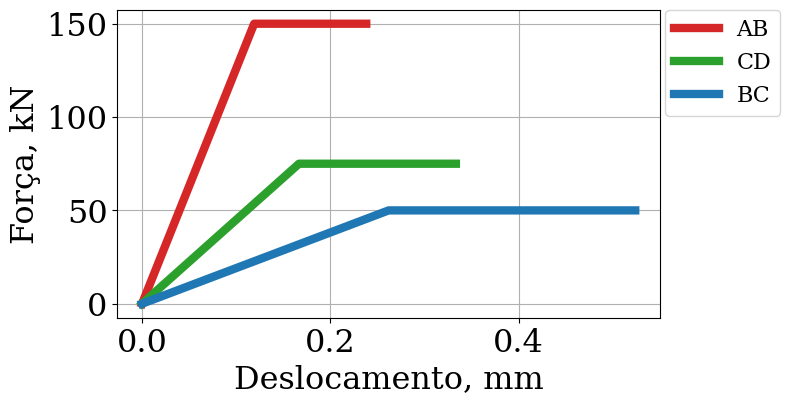

In [5]:
fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(1, 1, 1)
ax.plot([0,dABmax,2*dABmax], [0,FABmax*1e-3,FABmax*1e-3], color='tab:red', linewidth = 6, label='AB')
ax.plot([0,dCDmax,2*dCDmax], [0,FCDmax*1e-3,FCDmax*1e-3], color='tab:green', linewidth = 6, label='CD')
ax.plot([0,dBCmax,2*dBCmax], [0,FBCmax*1e-3,FBCmax*1e-3], color='tab:blue', linewidth = 6, label='BC')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0,fontsize=16)
plt.xlabel('Deslocamento, mm')
plt.ylabel('Força, kN')
plt.grid()
plt.show()

Como se pode verificar o troço menos rígido é o $BC$. Ocorrendo plasticidade, será este veio o primeiro a ceder.

Considere-se por hipótese o instante para o qual é atingido o limite de elasticidade da barra $BC$. Pelo arranjo em série dos elementos de barras, este instante condicionará o comportamento global da barra $AD$. Analisando o instante de cedência tem-se:

- Limite elasticidade barra $BC$: força máxima

    \begin{equation*}
    F^\textrm{max} = F_{BC}^\textrm{ced} = 50~\textrm{kN}
    \end{equation*}

- Limite elasticidade barra $BC$: delocamento total à força máxima (cedência da barra)

    \begin{equation*}
    \delta_{A/D}^{F^\textrm{max}} = \sum_i \delta_{i}^{F^\textrm{max}} =
     \left(\frac{F_{BC}^\mathrm{ced}L}{EA}\right)_{AB}
    + \delta_{BC}^\mathrm{ced}
    + \left(\frac{F_{BC}^\mathrm{ced}L}{EA}\right)_{CD}
    \end{equation*}

- Limite elasticidade barra $BC$: diagrama força-deslocamento do conjunto

(d,f)ced = (0.714, 50.0) [mm, kN]


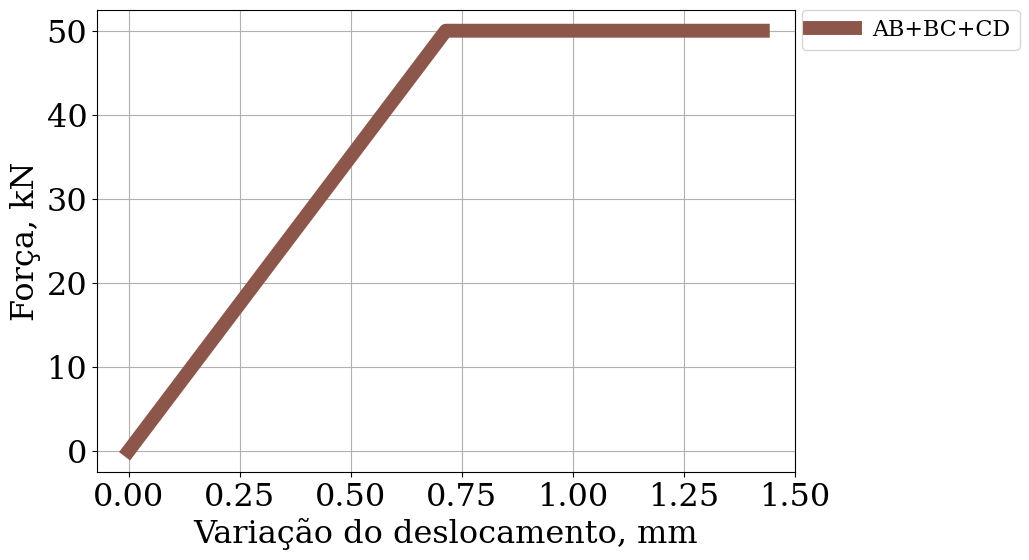

In [6]:
dconj = FABmax*LAB/E/AAB + dBCmax + FABmax*LCD/E/ACD
print(f'(d,f)ced = ({dconj:.3f}, {FBCmax*1e-3:.1f}) [mm, kN]')

fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(1, 1, 1)
plt.plot([0,dconj,2*dconj], [0,FBCmax*1e-3,FBCmax*1e-3], color='tab:brown',
         linewidth = 10, label='AB+BC+CD')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0,
         fontsize=16)
# plt.text(dconj*1.1, FBCmax*.9, f'({dconj:.3f},{FBCmax:3.1f})', fontsize=22)
plt.xlabel('Variação do deslocamento, mm')
plt.ylabel('Força, kN')
plt.grid()
plt.show()

**Aquecimento ($\Delta T >0$)**

Considere-se agora o aquecimento da barra como ilustrado na figura em baixo. Será que a barra irá plastificar com o aumento da temperatura? Comece-se por analisar a hipótese de que a barra permanece no domínio linear elástico e calcule-se a força axial gerada em cada troço da barra pelo aumento da temperatura.

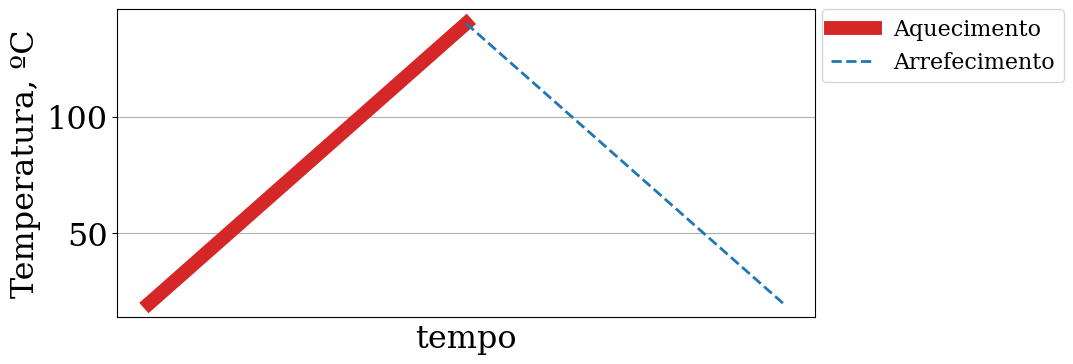

In [7]:
temp = [1,2,3]
fig = plt.figure(figsize=(9,4))
ax = fig.add_subplot(1, 1, 1)
plt.plot([temp[0],temp[1]], [Ti,Tf], color='tab:red',
         linewidth = 10, label='Aquecimento')
plt.plot([temp[1],temp[2]], [Tf,Ti], color='tab:blue',
         linewidth = 2, label='Arrefecimento', linestyle='--')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0,
         fontsize=16)
ax.get_xaxis().set_ticks([])
plt.xlabel('tempo')
plt.ylabel('Temperatura, ºC')
plt.grid()
plt.show()

A análise do problema recorre ao princípio de sobreposição, como ilustrado na figura:

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au10/Au10_P004_i2.jpg"
width="600" height="260">

Considere-se em primeiro lugar a barra com apenas um apoio do tipo encastramento e a outra extremidade livre. Esta nova barra é estaticamente equivalente. Por efeito de expansão térmica pelo aumento de temperatura a barra irá alongar (pelo bordo livre). Este alongamento pode ser obtido pela combinação linear dos respetivos aumentos dos troços que constituem o veio (com diferentes comprimentos, embora de um material com o mesmo coeficiente de expansão térmico). Por outro lado, considere-se sobreposta uma força redundante externa (que representa o efeito do encastramento no bordo livre a estrutura isostática equivalente). A equação de compatibilidade de deslocamentos permite escrever:

\begin{equation*}
\delta_{A/D} = 0
\quad\Leftrightarrow\quad
\delta_{A/D}^{\Delta T} - \delta_{A/D}^{F} = 0
\end{equation*}

De notar que $\delta_{A/D}^{\Delta T} > 0$ pois, por convenção, está associado a uma variação de temperatura positiva, enquanto $\delta_{A/D}^{F} < 0$ pois, pela análise do método das secções, o diagrama de esforço axial, $N(x)$ é compressivo.

Pela combinação em série dos troços, conclui-se:

\begin{equation*}
\begin{aligned}
\delta_{A/D}^{\Delta T} - \delta_{A/D}^{F} ~~ & =~~ 0 \\
\quad\Leftrightarrow\quad
\delta_{A/B}^{\Delta T} + \delta_{B/C}^{\Delta T} + \delta_{C/D}^{\Delta T}
~~ & =~~ \delta_{A/B}^{F} + \delta_{B/C}^{F} + \delta_{C/D}^{F} \\
\quad\Leftrightarrow\quad
\alpha\Delta T (L_{AB}+L_{BC}+L_{CD})
~~ & =~~ \frac{F}{E}\left(\frac{L_{AB}}{A_{AB}} + \frac{L_{BC}}{A_{BC}} +
\frac{L_{CD}}{A_{CD}} \right)\\
\end{aligned}
\end{equation*}

A força axial gerada pela variação de temperatura exercida na barra pelos apois fixo é calculado por:

In [8]:
F = coDilat*DT*(LAB+LBC+LCD)*E/(LAB/AAB+LBC/ABC+LCD/ACD)
print(f'F (DT - ºC) = {F*1e-3:.3f} kN')

F (DT - ºC) = 78.246 kN


Como $F > F_{BC}^\mathrm{ced}$ conclui-se que a barra $BC$ plastifica, sendo que os restantes troços permanecem com comportamento linear elástico.

Ou seja, pelo aumento da temperatura existe um reação mecânica de esforço axial aplicado de compressão (equilíbrio), que irá saturar ao nível da força de cedência da barra BC.

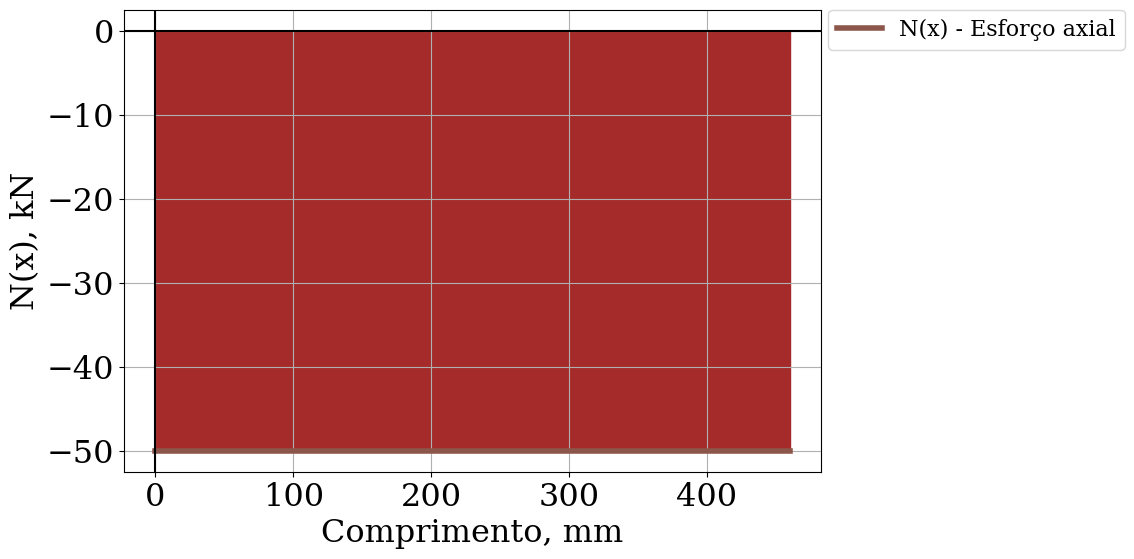

In [9]:
from matplotlib import patches
import matplotlib.pyplot as plt

coAD = LAB + LBC + LCD
Nx = -FBCmax # esforço de compressão
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(1, 1, 1)
plt.plot([0,coAD], [Nx*1e-3,Nx*1e-3], color='tab:brown',
         linewidth = 4, label='N(x) - Esforço axial')
rect1 = patches.Rectangle((0,0), coAD, Nx*1e-3, color='brown')
ax.add_patch(rect1)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0,
         fontsize=16)
plt.axvline(0, color='k', linestyle='solid')
plt.axhline(0, color='k', linestyle='solid')
plt.xlabel('Comprimento, mm')
plt.ylabel('N(x), kN')
plt.grid()
plt.show()

Nestas condições o estado de tensão normal em cada troço será proportional à área de secção de acordo com as seguintes relações:

\begin{equation*}
\sigma_{AB} = \displaystyle\frac{F_{BC}^{\mathrm{ced}}}{A_{AB}}~\textrm{(MPa)}\quad\wedge\quad
\sigma_{BC} = 250~\textrm{(MPa)}\quad\wedge\quad
\sigma_{CD} = \displaystyle\frac{F_{BC}^{\mathrm{ced}}}{A_{AB}}~\textrm{(MPa)}
\end{equation*}

sigma AB  (F(DT)) = -83.33 MPa (compressão)
sigma BC  (F(DT)) = -250.00 MPa (compressão)
sigma CD  (F(DT)) = -166.67 MPa (compressão)


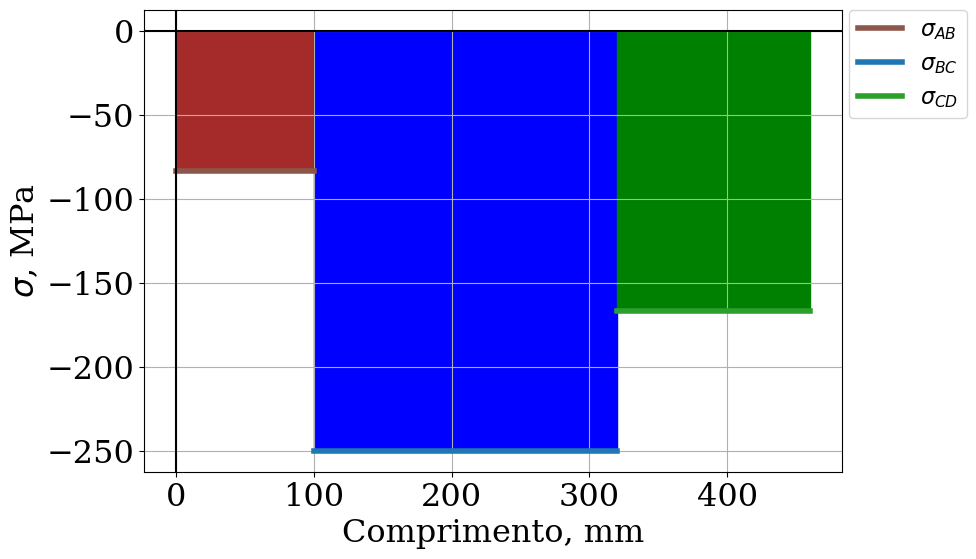

In [10]:
sigmaAB = Nx/AAB
print(f'sigma AB  (F(DT)) = {sigmaAB:.2f} MPa (compressão)')
sigmaBC = -Sced
print(f'sigma BC  (F(DT)) = {sigmaBC:.2f} MPa (compressão)')
sigmaCD = Nx/ACD
print(f'sigma CD  (F(DT)) = {sigmaCD:.2f} MPa (compressão)')

fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(1, 1, 1)
plt.plot([0,LAB], [sigmaAB,sigmaAB], color='tab:brown',
         linewidth = 4, label=r'$\sigma_{AB}$')
plt.plot([LAB,LAB+LBC], [sigmaBC,sigmaBC], color='tab:blue',
         linewidth = 4, label=r'$\sigma_{BC}$')
plt.plot([LAB+LBC,LAB+LBC+LCD], [sigmaCD,sigmaCD], color='tab:green',
         linewidth = 4, label=r'$\sigma_{CD}$')
rect1 = patches.Rectangle((0,0), LAB, sigmaAB, color='brown')
ax.add_patch(rect1)
rect2 = patches.Rectangle((LAB,0), LBC, sigmaBC, color='blue')
ax.add_patch(rect2)
rect3 = patches.Rectangle((LAB+LBC,0), LCD, sigmaCD, color='green')
ax.add_patch(rect3)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0,
         fontsize=16)
plt.axvline(0, color='k', linestyle='solid')
plt.axhline(0, color='k', linestyle='solid')
plt.xlabel('Comprimento, mm')
plt.ylabel(r'$\sigma$, MPa')
plt.grid()
plt.show()

#### b) Obtenha as tensões em cada troço depois da barra arrefecer até à temperatura ambiente. <a id="B"></a> ([enunciatum](#PIV104))

**Arrefecimento ($\Delta T <0$)**

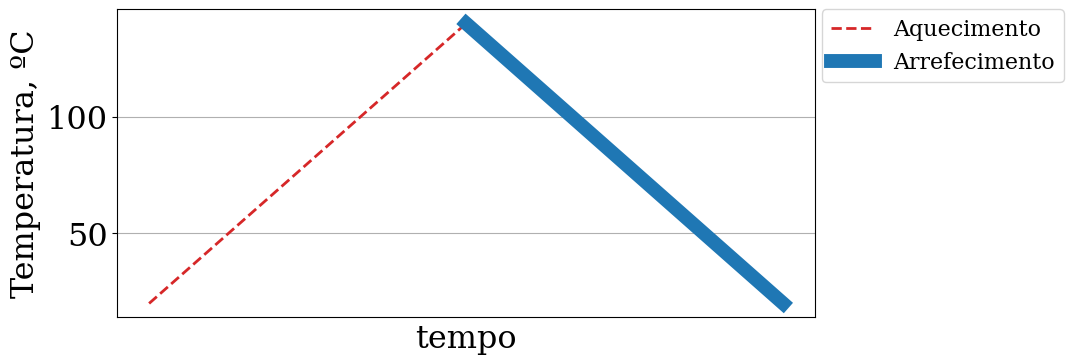

In [11]:
temp = [1,2,3]
fig = plt.figure(figsize=(9,4))
ax = fig.add_subplot(1, 1, 1)
plt.plot([temp[0],temp[1]], [Ti,Tf], color='tab:red',
         linewidth = 2, label='Aquecimento', linestyle='--')
plt.plot([temp[1],temp[2]], [Tf,Ti], color='tab:blue',
         linewidth = 10, label='Arrefecimento')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0,
         fontsize=16)
ax.get_xaxis().set_ticks([])
plt.xlabel('tempo')
plt.ylabel('Temperatura, ºC')
plt.grid()
plt.show()

Considerando o ciclo de descarga no arrefecimento da barra.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au10/Au10_P004_i3.jpg"
width="700">

A equação de compatibilidade de deslocamentos na secção $D$ (pela remoção do encastramento)  permite escrever:

\begin{equation*}
\begin{aligned}
& - \delta_{A/D}^{-\Delta T} + \delta_{A/D}^{F} = 0 \\
\quad\Leftrightarrow\quad& - (\delta_{A/B}^{-\Delta T} +
\delta_{B/C}^{-\Delta T}
 + \delta_{C/D}^{-\Delta T}) +
\left[\delta_{A/B}^{e} + (\delta_{B/C}^{e} + \delta_{B/C}^p) +
\delta_{C/D}^{e}\right] = 0\\
\quad\Leftrightarrow\quad&
\delta_{B/C}^p = \delta_{A/D}^{-\Delta T} - \delta_{A/D}^{e}
 \\
\quad\Leftrightarrow\quad &
\delta_{B/C}^p = \alpha(|\Delta T|) (L_{AB}+L_{BC}+L_{CD})
- \frac{F_{BC}^\mathrm{max}}{E}\left(\frac{L_{AB}}{A_{AB}} +
\frac{L_{BC}}{A_{BC}} + \frac{L_{CD}}{A_{CD}} \right)\\
\end{aligned}
\end{equation*}

In [12]:
deslPlas = coDilat*DT*(LAB+LBC+LCD) - FBCmax/E*(LAB/AAB+LBC/ABC+LCD/ACD)
print(f'desl. plastico = {deslPlas:.3f} mm')

desl. plastico = 0.233 mm


Após terminar o ciclo térmico existirá uma deformação permanente, que dará origem a uma força residual. O valor dessa força pode ser calculado por:

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au10/Au10_P004_i4.jpg"
width="600" height="210">

\begin{equation*}
\begin{aligned}
\delta^{R} \equiv \delta^{F_R} \equiv \delta_{B/C}^P =
\frac{F^\mathrm{R}}{E}\left
(\frac{L_{AB}}{A_{AB}} + \frac{L_{BC}}{A_{BC}} + \frac{L_{CD}}{A_{CD}} \right)\\
\end{aligned}
\end{equation*}

Resolvendo para a força residual,

\begin{equation*}
\begin{aligned}
F^\mathrm{R} =
\frac{\delta_{B/C}^PE}{ L_{AB}/A_{AB} + L_{BC}/A_{BC} + L_{CD}/A_{CD}}
\end{aligned}
\end{equation*}

In [13]:
FResiduo = deslPlas*E/(LAB/AAB+LBC/ABC+LCD/ACD)
print(f'força residual instalada = {FResiduo*1e-3:.1f} kN')

força residual instalada = 28.2 kN


Pelo que as tensões residuais instaladas nos troços do veio são:

\begin{equation*}
\sigma_{AB}^R = \displaystyle\frac{F^\mathrm{R}}{A_{AB}}~\textrm{(MPa)}\quad\wedge\quad
\sigma_{BC}^R = \displaystyle\frac{F^\mathrm{R}}{A_{BC}}~\textrm{(MPa)}\quad\wedge\quad
\sigma_{CD}^R = \displaystyle\frac{F^\mathrm{R}}{A_{AB}}~\textrm{(MPa)}
\end{equation*}

In [14]:
sigmaABarr = FResiduo/AAB
print(f'sigma AB  (F(DT)) = {sigmaABarr:.2f} MPa (tração)')
sigmaBCarr = FResiduo/ABC
print(f'sigma BC  (F(DT)) = {sigmaBCarr:.2f} MPa (tração)')
sigmaCDarr = FResiduo/ACD
print(f'sigma CD  (F(DT)) = {sigmaCDarr:.2f} MPa (tração)')

sigma AB  (F(DT)) = 47.08 MPa (tração)
sigma BC  (F(DT)) = 141.23 MPa (tração)
sigma CD  (F(DT)) = 94.15 MPa (tração)


**Método 2: Tensões residuais** (alternativa)

A tensão normal em cada troço da barra para o momento de aquecimento a $T$ = 140 ºC foi já calculada na alínea a). Se a este estado de tensão for subtraida a tensão de recuperação elástica gerada no arrefecimento, a diferença entre estes dois estados de tensão será a tensão residual.

\begin{equation*}
\delta_\textrm{arrefecimento} = |\delta_{A/D}^{-\Delta T}| = |\delta_{A/D}^{F}|
\end{equation*}

pelo que,

\begin{equation*}
\begin{aligned}
\delta_\textrm{arrefecimento} &=
\alpha(\Delta T) (L_{AB}+L_{BC}+L_{CD})
= \alpha(\Delta T) L_{AC} =\delta_{B/C}^p + \frac{F_{BC}^\mathrm{max}}{E}\left(\frac{L_{AB}}{A_{AB}} +
\frac{L_{BC}}{A_{BC}} + \frac{L_{CD}}{A_{CD}}\right)
\end{aligned}
\end{equation*}

Este alongamento total dará origem a uma força total de recuperação elástica:

\begin{equation*}
F_\textrm{arrefecimento} = \frac{\delta_\textrm{arrefecimento}E}{\left(\frac{L_{AB}}{A_{AB}} +
\frac{L_{BC}}{A_{BC}} + \frac{L_{CD}}{A_{CD}}\right)}
\end{equation*}

In [15]:
d_arref1 = coDilat*DT*(LAB+LBC+LCD)
print(f'  contração elástica (arrefecimento) (cal 1) = {d_arref1} mm')
d_arref2 = deslPlas + FBCmax/E*(LAB/AAB+LBC/ABC+LCD/ACD)
print(f'alongamento elástica (arrefecimento) (cal 2) = {d_arref2} mm')

f_arref = d_arref1*E/(LAB/AAB+LBC/ABC+LCD/ACD)
print(f'força elástica total (arrefecimento) (cal 2) = {f_arref} N')

print(f'\n    tensão barra AB (aquecimento) = {sigmaAB:.2f} MPa')
print(f'    tensão barra BC (aquecimento) = {sigmaBC:.2f} MPa')
print(f'    tensão barra CD (aquecimento) = {sigmaCD:.2f} MPa')

  contração elástica (arrefecimento) (cal 1) = 0.64584 mm
alongamento elástica (arrefecimento) (cal 2) = 0.64584 mm
força elástica total (arrefecimento) (cal 2) = 78246.0 N

    tensão barra AB (aquecimento) = -83.33 MPa
    tensão barra BC (aquecimento) = -250.00 MPa
    tensão barra CD (aquecimento) = -166.67 MPa



A tensão residual em cada troço da barra será dada por:

\begin{equation*}
\begin{aligned}
\sigma_{AB}^R = (\sigma_{AB})_\textrm{aquecimento}^c + (\sigma_{AB})
_\textrm{arrefecimento}^t \\
\sigma_{BC}^R = (\sigma_{BC})_\textrm{aquecimento}^c + (\sigma_{BC})
_\textrm{arrefecimento}^t \\
\sigma_{CD}^R = (\sigma_{CD})_\textrm{aquecimento}^c + (\sigma_{CD})
_\textrm{arrefecimento}^t
\end{aligned}
\end{equation*}

com $c$ - compressão e $t$ - tração.

In [16]:
sigAB_arref = f_arref/AAB
print(f'\n  tensão barra AB (arrefecimento) = {sigAB_arref} MPa')
sigBC_arref = f_arref/ABC
print(f'  tensão barra BC (arrefecimento) = {sigBC_arref} MPa')
sigCD_arref = f_arref/ACD
print(f'  tensão barra CD (arrefecimento) = {sigCD_arref} MPa')

sigAB_residual = sigmaAB + sigAB_arref
print(f'\n       tensão barra AB (residual) = {sigAB_residual:.2f} MPa')
sigBC_residual = sigmaBC + sigBC_arref
print(f'       tensão barra BC (residual) = {sigBC_residual:.2f} MPa')
sigCD_residual = sigmaCD + sigCD_arref
print(f'       tensão barra CD (residual) = {sigCD_residual:.2f} MPa')


  tensão barra AB (arrefecimento) = 130.41 MPa
  tensão barra BC (arrefecimento) = 391.23 MPa
  tensão barra CD (arrefecimento) = 260.82 MPa

       tensão barra AB (residual) = 47.08 MPa
       tensão barra BC (residual) = 141.23 MPa
       tensão barra CD (residual) = 94.15 MPa


#### c) Calcule a distância que a secção C distará da secção A depois da barra arrefecer. <a id="C"></a> ([enunciatum](#PIV104))

Considere-se a barra total $AD$ seccionada em $C$, nas partes $AC$ e $CD$. O diagram de corpo livre, de ambas as partes, resulta em:

Olhando para o troço $CD$ que permanece no domínio linear elástico, a força residual instalada irá gerar um alongamento da barra

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au10/Au10_P004_i5.jpg"
width="600" height="180">

As secções $AC$ e $CD$ estáo submetidas a forças de tração cujo módulo é a força residual após o ciclo térmico aquecimento-arrefecimento.

**Troço CD**

Da análise do troço $CD$ resulta:

\begin{equation*}
\delta_{CD}^{F_R} = \frac{F^RL_{CD}}{EA_{CD}}
\quad\wedge\quad
L_{C'D}^\mathrm{final} = L_{CD}^\mathrm{inicial} + \delta_{CD}^{F_R}
\end{equation*}

In [17]:
deltaCRes = FResiduo*LCD/ACD/E
print(f'desl C residual = {deltaCRes:.4f} mm')

LCDfinal = LCD + deltaCRes
print(f'LCD inicial = {LCD:.3f} mm')
print(f'LCD final (F. residual) = {LCDfinal:.3f} mm')

desl C residual = 0.0628 mm
LCD inicial = 140.000 mm
LCD final (F. residual) = 140.063 mm


**Troço AC**

O ponto $C$ aproxima-se do encastramento em $A$ de $\delta_{CD}^{F_R}$. A variação de comprimento permite calcular:

\begin{equation*}
\begin{aligned}
L_{AC}^\mathrm{final} = L_{AC}^\mathrm{inicial} - \delta_{CD}^{F_R}
\end{aligned}
\end{equation*}

In [18]:
LAC = LAB+LBC
LACfinal = LAC - deltaCRes
print(f'LAC inicial = {LAC:.3f} mm')
print(f'LAC final (F. residual) = {LACfinal:.3f} mm')

print('\nverificação: ----------')
print(f'LAC inicial + LCD inicial = {LAC+LCD:.1f} mm')
print(f'    LAC final + LCD final = {LACfinal+LCDfinal:.1f} mm')

LAC inicial = 320.000 mm
LAC final (F. residual) = 319.937 mm

verificação: ----------
LAC inicial + LCD inicial = 460.0 mm
    LAC final + LCD final = 460.0 mm


Numa resolução alternativa, de forma equivalente (ver diagrama de corpo livre da figura):

\begin{equation*}
L_{AC'} = L_{AB} + \delta_{AB}^{F_R} + L_{BC} - \delta_{BC}^P +
\delta_{BC}^{F_R}
\end{equation*}

In [19]:
dFrAB = FResiduo*LAB/E/AAB
print(f'alongamento barra AB FResidual = {dFrAB:4f} mm')
dFrBC = FResiduo*LBC/E/ABC
print(f'alongamento barra BC FResidual = {dFrBC:4f} mm')
LACfinal2 = LAC + dFrAB + dFrBC - deslPlas
print(f'LAC inicial = {LAC:.3f} mm')
print(f'LAC final (F. residual) = {LACfinal2:.3f} mm')

alongamento barra AB FResidual = 0.022417 mm
alongamento barra BC FResidual = 0.147955 mm
LAC inicial = 320.000 mm
LAC final (F. residual) = 319.937 mm


---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
